# Notebook 04 — Analisi Storica dello Spopolamento (2018–2026)
**Capstone: Aree Interne Italiane** 


In [1]:
import os
os.chdir(r'C:\Users\tomma\OneDrive\Desktop\EPICODE\CAPSTONE_2')
print("Working directory:", os.getcwd())

Working directory: C:\Users\tomma\OneDrive\Desktop\EPICODE\CAPSTONE_2


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")
PROCESSED_DIR = "data/processed/"
OUTPUT_DIR    = "outputs/"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Setup OK")

Setup OK


## 1. Caricamento Dati (2018–2026)

In [3]:
df_long = pd.read_csv(PROCESSED_DIR + "pop_storica_comuni_long.csv",
                      dtype={"codice_comune": str})
df_long["anno"] = df_long["anno"].astype(int)
df_long["popolazione"] = pd.to_numeric(df_long["popolazione"], errors="coerce")

df_wide = pd.read_csv(PROCESSED_DIR + "pop_storica_comuni_wide.csv",
                      dtype={"codice_comune": str})

ANNI = sorted(df_long["anno"].unique().tolist())
print(f"LONG: {len(df_long):,} righe | Anni: {ANNI}")
print(f"WIDE: {len(df_wide):,} comuni")
print(f"Comuni con var 2018-2026: {df_wide['var_pct_18_26'].notna().sum():,}")
df_wide[["codice_comune","comune","pop_2018","pop_2023","pop_2024","pop_2025","pop_2026",
         "var_pct_18_26","var_pct_23_26","tipo_area"]].head(3)

LONG: 71,171 righe | Anni: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
WIDE: 7,991 comuni
Comuni con var 2018-2026: 7,859


,codice_comune,comune,pop_2018,pop_2023,pop_2024,pop_2025,pop_2026,var_pct_18_26,var_pct_23_26,tipo_area
0,001001,Agliè,2634.0,2596.0,2596.0,2585.0,2584.0,-1.898,-0.462,Cintura
1,001002,Airasca,3613.0,3686.0,3686.0,3695.0,3698.0,2.353,0.326,Cintura
2,001003,Ala di Stura,442.0,472.0,472.0,463.0,468.0,5.882,-0.847,Periferico


## 2. Statistiche Variazione Demografica 2018–2026
Quanti comuni sono in calo? Distribuzione per classe SNAI.

In [4]:
df_v = df_wide[df_wide["var_pct_18_26"].notna()].copy()
n_calo     = (df_v["var_pct_18_26"] < 0).sum()
n_crescita = (df_v["var_pct_18_26"] > 0).sum()
n_stabile  = (df_v["var_pct_18_26"] == 0).sum()
n_tot      = len(df_v)
print(f"Comuni totali analizzati:   {n_tot:,}")
print(f"In CALO    (< 0%):          {n_calo:,} ({100*n_calo/n_tot:.1f}%)")
print(f"In CRESCITA (> 0%):         {n_crescita:,} ({100*n_crescita/n_tot:.1f}%)")
print(f"Stabili    (= 0%):          {n_stabile:,} ({100*n_stabile/n_tot:.1f}%)")
print()
print("Variazione % media per tipo area (2018-2026):")
order = ["Polo","Polo Intercomunale","Cintura","Intermedio","Periferico","Ultraperiferico"]
order_map = {v:i for i,v in enumerate(order)}
stat = df_v[df_v["tipo_area"].isin(order)].groupby("tipo_area")["var_pct_18_26"]\
           .agg(["mean","median","min","max"]).round(2)
stat["_ord"] = stat.index.map(order_map)
print(stat.sort_values("_ord").drop(columns=["_ord"]).to_string())

Comuni totali analizzati:   7,859
In CALO    (< 0%):          5,604 (71.3%)
In CRESCITA (> 0%):         2,217 (28.2%)
Stabili    (= 0%):          38 (0.5%)

Variazione % media per tipo area (2018-2026):
                    mean  median    min    max
tipo_area                                     
Polo               -1.18   -1.23  -7.67  16.25
Polo Intercomunale -1.07   -1.65 -17.58   9.12
Cintura            -1.33   -1.25 -21.13  41.14
Intermedio         -3.51   -3.50 -53.75  29.36
Periferico         -5.63   -5.76 -28.66  33.33
Ultraperiferico    -6.71   -6.87 -31.04  63.17


## 3. Trend per Classe SNAI — Indice Base 2018 = 100
Linea continua = dati definitivi ISTAT (2018-2023). Tratteggiata = POSAS 2024-2026.

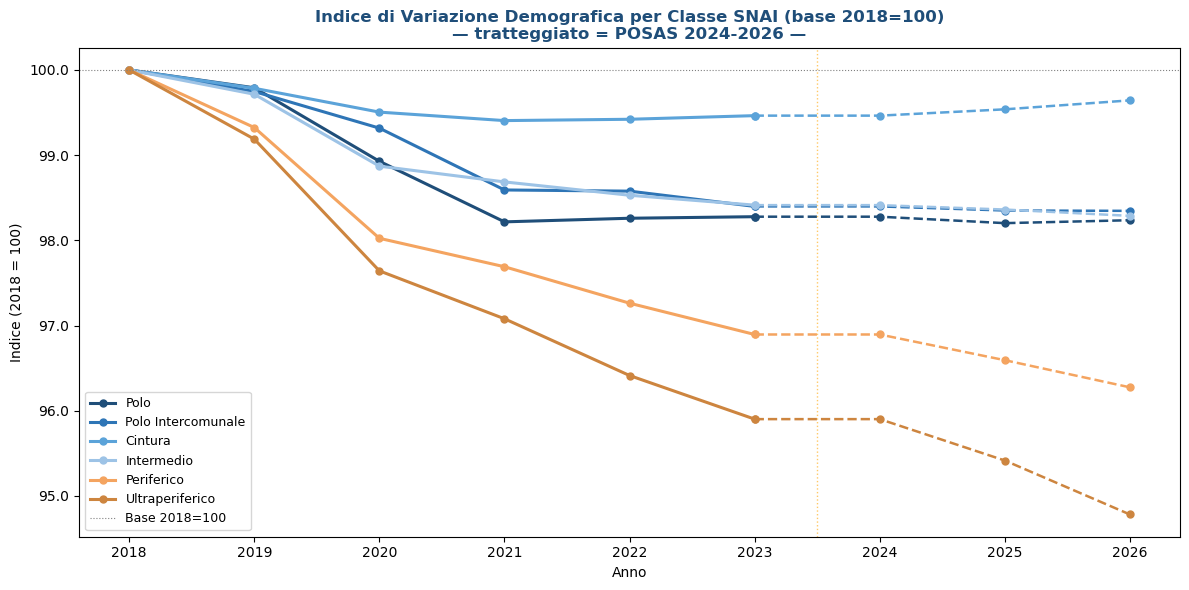

In [5]:
order  = ["Polo","Polo Intercomunale","Cintura","Intermedio","Periferico","Ultraperiferico"]
colori = ["#1F4E79","#2E75B6","#5BA3D9","#9DC3E6","#F4A460","#CD853F"]

df_trend = df_long[
    df_long["tipo_area"].isin(order) & df_long["popolazione"].notna()
].groupby(["tipo_area","anno"])["popolazione"].mean().reset_index()

base = df_trend[df_trend["anno"]==2018].set_index("tipo_area")["popolazione"]
df_trend["indice"] = df_trend.apply(
    lambda r: r["popolazione"] / base.get(r["tipo_area"], np.nan) * 100, axis=1)

fig, ax = plt.subplots(figsize=(12,6))
for i, tipo in enumerate(order):
    sub = df_trend[df_trend["tipo_area"]==tipo].sort_values("anno")
    if len(sub)==0: continue
    sub_s = sub[sub["anno"]<=2023]
    sub_p = sub[sub["anno"]>=2023]
    ax.plot(sub_s["anno"].tolist(), sub_s["indice"].tolist(),
            marker="o", linewidth=2.2, color=colori[i], label=str(tipo), markersize=5)
    ax.plot(sub_p["anno"].tolist(), sub_p["indice"].tolist(),
            linestyle="--", linewidth=1.8, color=colori[i], marker="o", markersize=5)

ax.axhline(100, color="gray", linewidth=0.8, linestyle=":", label="Base 2018=100")
ax.axvline(2023.5, color="orange", linewidth=1, linestyle=":", alpha=0.6)
ax.set_title("Indice di Variazione Demografica per Classe SNAI (base 2018=100)\n"
             "— tratteggiato = POSAS 2024-2026 —",
             fontsize=12, fontweight="bold", color="#1F4E79")
ax.set_ylabel("Indice (2018 = 100)")
ax.set_xlabel("Anno")
ax.set_xticks(ANNI)
ax.legend(fontsize=9, loc="lower left")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
plt.tight_layout()
plt.savefig(OUTPUT_DIR+"nb04_indice_trend_snai.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Boxplot Variazione % 2018–2026 per Classe SNAI

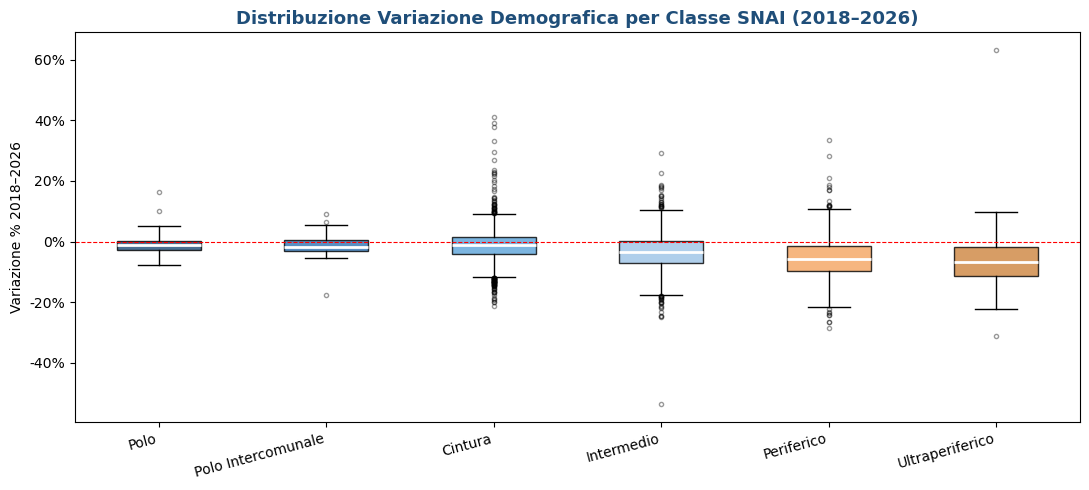

In [6]:
order  = ["Polo","Polo Intercomunale","Cintura","Intermedio","Periferico","Ultraperiferico"]
colori = ["#1F4E79","#2E75B6","#5BA3D9","#9DC3E6","#F4A460","#CD853F"]
gruppi = [df_wide[df_wide["tipo_area"]==t]["var_pct_18_26"].dropna().tolist() for t in order]
gv = [(t,g) for t,g in zip(order,gruppi) if len(g)>0]
labels_box=[t for t,_ in gv]; dati_box=[g for _,g in gv]
col_box=[colori[order.index(t)] for t in labels_box]

fig, ax = plt.subplots(figsize=(11,5))
bp = ax.boxplot(dati_box, patch_artist=True,
                medianprops={"color":"white","linewidth":2},
                flierprops={"marker":"o","markersize":3,"alpha":0.4})
for patch,color in zip(bp["boxes"],col_box):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_xticklabels(labels_box, rotation=15, ha="right")
ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
ax.set_ylabel("Variazione % 2018–2026")
ax.set_title("Distribuzione Variazione Demografica per Classe SNAI (2018–2026)",
             fontsize=13, fontweight="bold", color="#1F4E79")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
plt.tight_layout()
plt.savefig(OUTPUT_DIR+"nb04_boxplot_variazione_snai.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Top 20 Comuni con Maggior Calo Demografico (2018–2026)

                         comune   regione       tipo_area  pop_2018  pop_2026  var_pct_18_26
               Rocca de' Giorgi Lombardia      Intermedio      80.0      37.0        -53.750
           Roccaforte del Greco  Calabria Ultraperiferico     422.0     291.0        -31.043
                      San Biase    Molise      Periferico     164.0     117.0        -28.659
                         Staiti  Calabria      Periferico     219.0     161.0        -26.484
                     Marcetelli     Lazio      Periferico      72.0      53.0        -26.389
                         Isasca  Piemonte      Intermedio      84.0      63.0        -25.000
         Castellino del Biferno    Molise      Intermedio     552.0     417.0        -24.457
                        Terelle     Lazio      Intermedio     348.0     263.0        -24.425
                    Castelmauro    Molise      Periferico    1421.0    1075.0        -24.349
                    Roccavivara    Molise      Periferico     749.0   

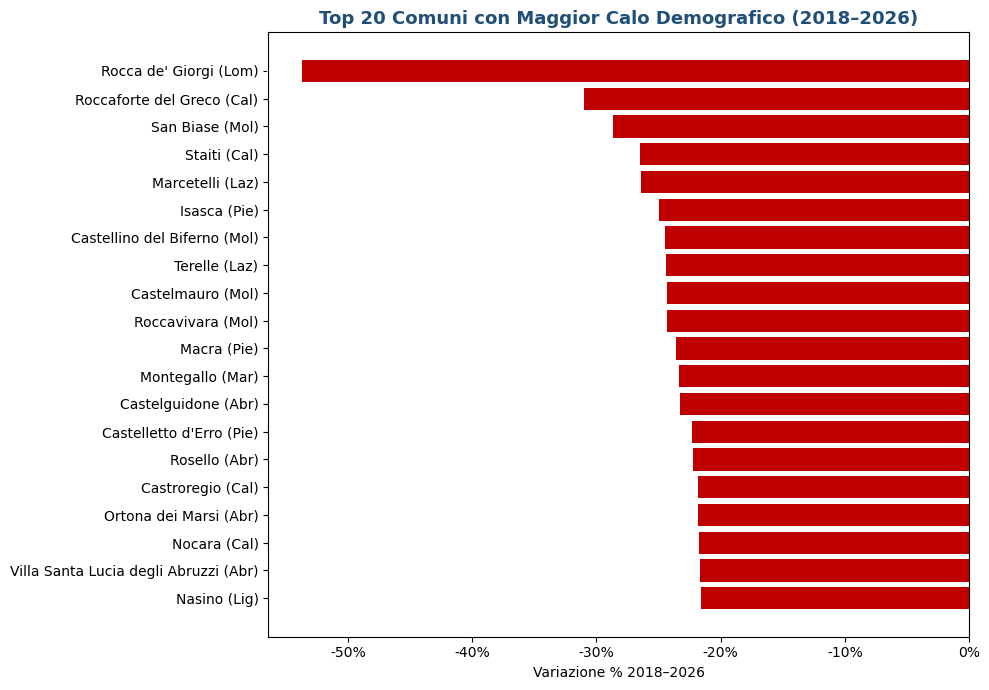

In [7]:
top_calo = df_wide[
    df_wide["var_pct_18_26"].notna() & df_wide["tipo_area"].notna() &
    df_wide["pop_2018"].notna()
].nsmallest(20,"var_pct_18_26").copy()
print(top_calo[["comune","regione","tipo_area","pop_2018","pop_2026","var_pct_18_26"]].to_string(index=False))

lab_c = [str(r["comune"])+" ("+str(r["regione"])[:3]+")" for _,r in top_calo.iterrows()]
val_c = top_calo["var_pct_18_26"].tolist()
fig, ax = plt.subplots(figsize=(10,7))
bars = ax.barh(lab_c, val_c, color="#C00000")
ax.set_xlabel("Variazione % 2018–2026")
ax.set_title("Top 20 Comuni con Maggior Calo Demografico (2018–2026)",
             fontsize=13, fontweight="bold", color="#1F4E79")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.invert_yaxis()
for bar,val in zip(bars,val_c):
    ax.text(val-0.3, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", ha="right", va="center", fontsize=8, color="white")
plt.tight_layout()
plt.savefig(OUTPUT_DIR+"nb04_top_calo.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Top 15 Comuni con Maggior Crescita (2018–2026, min 200 ab.)

               comune                      regione       tipo_area  pop_2018  pop_2026  var_pct_18_26
      Alagna Valsesia                     Piemonte Ultraperiferico     448.0     731.0         63.170
           Longobardi                     Calabria         Cintura    2280.0    3218.0         41.140
   Fiumefreddo Bruzio                     Calabria         Cintura    2886.0    3979.0         37.872
           San Lucido                     Calabria         Cintura    5842.0    7775.0         33.088
  Torre de' Picenardi                    Lombardia         Cintura    1686.0    2183.0         29.478
       Ronco Canavese                     Piemonte      Periferico     299.0     383.0         28.094
San Michele all'Adige Trentino-Alto Adige/Südtirol         Cintura    3228.0    4098.0         26.952
      Castel Gabbiano                    Lombardia         Cintura     438.0     542.0         23.744
Campospinoso Albaredo                    Lombardia         Cintura    1083.0    13

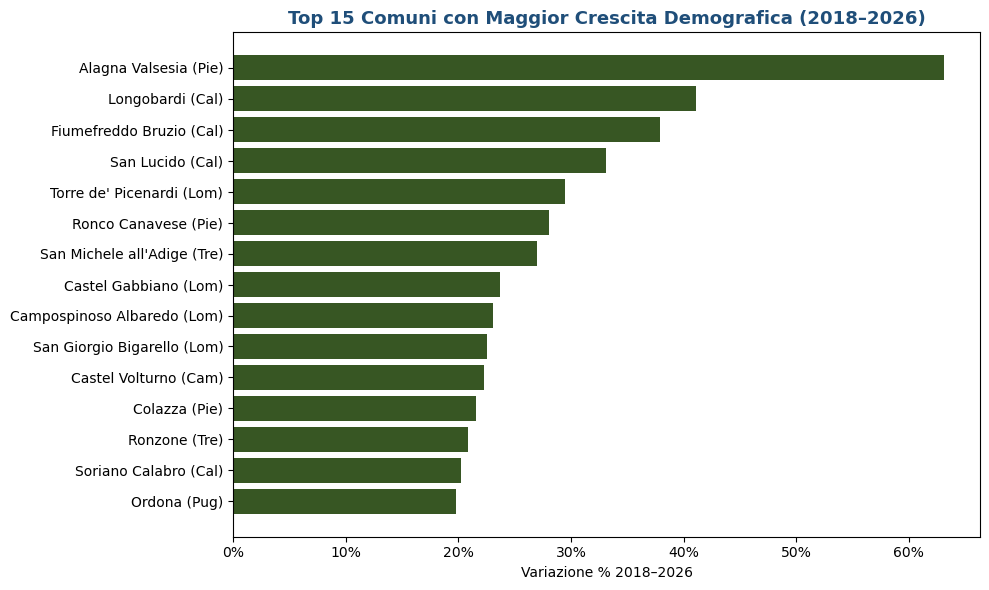

In [8]:
top_cresc = df_wide[
    df_wide["var_pct_18_26"].notna() & df_wide["tipo_area"].notna() &
    (df_wide["pop_2018"] >= 200)
].nlargest(15,"var_pct_18_26").copy()
print(top_cresc[["comune","regione","tipo_area","pop_2018","pop_2026","var_pct_18_26"]].to_string(index=False))

lab_cr=[str(r["comune"])+" ("+str(r["regione"])[:3]+")" for _,r in top_cresc.iterrows()]
val_cr=top_cresc["var_pct_18_26"].tolist()
fig, ax = plt.subplots(figsize=(10,6))
ax.barh(lab_cr, val_cr, color="#375623")
ax.set_xlabel("Variazione % 2018–2026")
ax.set_title("Top 15 Comuni con Maggior Crescita Demografica (2018–2026)",
             fontsize=13, fontweight="bold", color="#1F4E79")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR+"nb04_top_crescita.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Spopolamento nelle Aree Interne per Regione (2018–2026)

                     regione  n_comuni  var_media  comuni_in_calo  pct_comuni_calo
                      Molise       104 -10.143952             102             98.1
                  Basilicata       119  -9.615613             115             96.6
                     Abruzzo       202  -8.310678             185             91.6
                    Calabria       280  -8.190189             254             90.7
                      Marche       102  -7.059186              92             90.2
                    Campania       290  -6.504066             264             91.0
                     Sicilia       310  -5.583958             259             83.5
       Friuli-Venezia Giulia        82  -5.393439              75             91.5
                      Puglia       147  -4.877170             129             87.8
                    Piemonte       369  -4.606835             302             81.8
                      Umbria        48  -4.454750              43             89.6
    

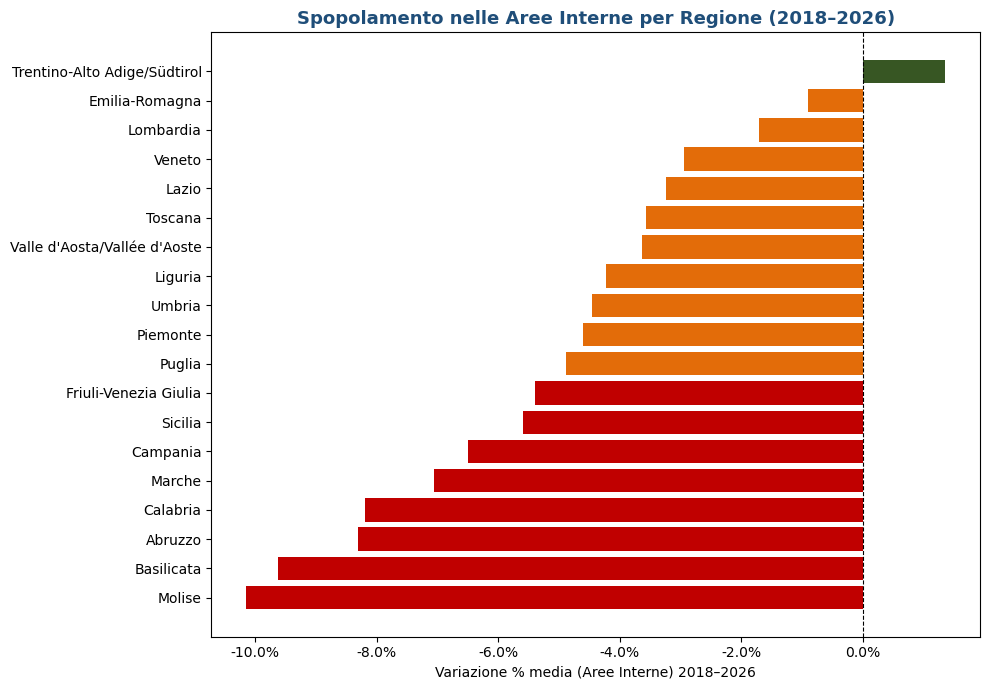

In [9]:
df_ai_v = df_wide[
    (df_wide["is_area_interna"]==1) &
    df_wide["var_pct_18_26"].notna() & df_wide["regione"].notna()
].copy()
reg_stat = df_ai_v.groupby("regione")["var_pct_18_26"].agg(
    n_comuni="count", var_media="mean",
    comuni_in_calo=lambda x:(x<0).sum()
).reset_index()
reg_stat["pct_comuni_calo"]=(reg_stat["comuni_in_calo"]/reg_stat["n_comuni"]*100).round(1)
reg_stat=reg_stat.sort_values("var_media")
print(reg_stat.to_string(index=False))

lab_r=reg_stat["regione"].tolist(); val_r=reg_stat["var_media"].tolist()
col_r=["#C00000" if v<-5 else "#E36C09" if v<0 else "#375623" for v in val_r]
fig, ax = plt.subplots(figsize=(10,7))
ax.barh(lab_r, val_r, color=col_r)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Variazione % media (Aree Interne) 2018–2026")
ax.set_title("Spopolamento nelle Aree Interne per Regione (2018–2026)",
             fontsize=13, fontweight="bold", color="#1F4E79")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
plt.tight_layout()
plt.savefig(OUTPUT_DIR+"nb04_spopolamento_regioni.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Confronto: 2018–2023 vs 2023–2026 per Classe SNAI
Il calo demografico ha accelerato nel periodo più recente (POSAS)?

Variazione media % per classe SNAI:
         tipo_area  var_18_23  var_23_26
              Polo  -1.307455   0.123972
Polo Intercomunale  -1.154684   0.063965
           Cintura  -1.357251   0.009676
        Intermedio  -3.067427  -0.497107
        Periferico  -4.516362  -1.226514
   Ultraperiferico  -5.235958  -1.610190


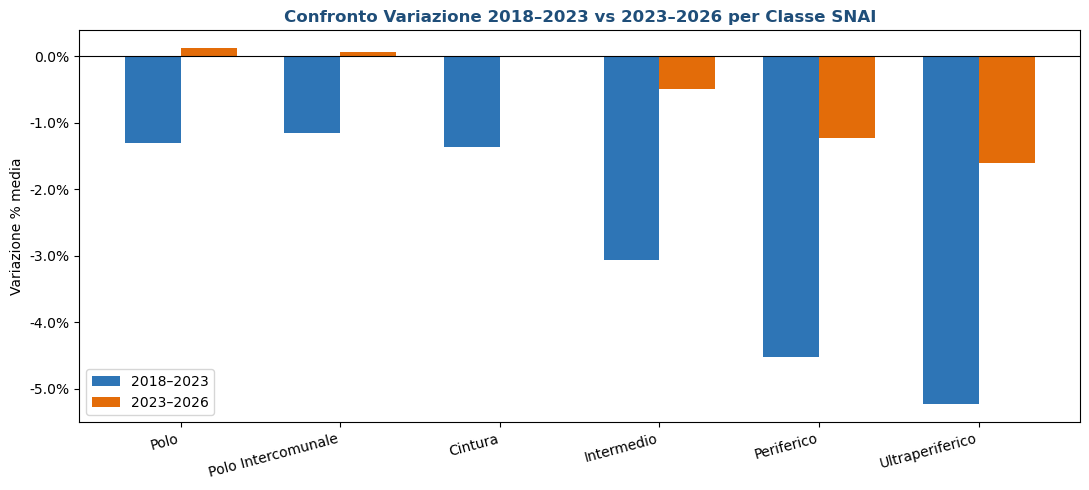

In [10]:
order = ["Polo","Polo Intercomunale","Cintura","Intermedio","Periferico","Ultraperiferico"]
df_wide["var_pct_18_23"] = ((df_wide["pop_2023"]-df_wide["pop_2018"])
                             /df_wide["pop_2018"]*100).round(3)

cmp = df_wide[df_wide["tipo_area"].isin(order)].groupby("tipo_area").agg(
    var_18_23=("var_pct_18_23","mean"),
    var_23_26=("var_pct_23_26","mean")
).reset_index()
cmp["_ord"]=cmp["tipo_area"].map({v:i for i,v in enumerate(order)})
cmp=cmp.sort_values("_ord").drop(columns=["_ord"])
print("Variazione media % per classe SNAI:")
print(cmp.to_string(index=False))

x=range(len(cmp)); w=0.35
fig, ax = plt.subplots(figsize=(11,5))
ax.bar([i-w/2 for i in x], cmp["var_18_23"].tolist(), w, label="2018–2023", color="#2E75B6")
ax.bar([i+w/2 for i in x], cmp["var_23_26"].tolist(), w, label="2023–2026", color="#E36C09")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(cmp["tipo_area"].tolist(), rotation=15, ha="right")
ax.set_ylabel("Variazione % media")
ax.set_title("Confronto Variazione 2018–2023 vs 2023–2026 per Classe SNAI",
             fontsize=12, fontweight="bold", color="#1F4E79")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
plt.tight_layout()
plt.savefig(OUTPUT_DIR+"nb04_confronto_periodi.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Export per Power BI

In [11]:
df_ls=df_long.sort_values(["codice_comune","anno"]).copy()
df_ls["pop_anno_prec"]=df_ls.groupby("codice_comune")["popolazione"].shift(1)
df_ls["var_pct_yoy"]=((df_ls["popolazione"]-df_ls["pop_anno_prec"])
                       /df_ls["pop_anno_prec"]*100).round(2)

col_pbi=["codice_comune","comune","anno","popolazione","var_pct_yoy",
         "regione","ripartizione","macro_area","classe_snai","tipo_area","is_area_interna"]
col_ok=[c for c in col_pbi if c in df_ls.columns]
df_pbi=df_ls[col_ok].copy()
df_pbi.to_csv(PROCESSED_DIR+"spopolamento_powerbi.csv", index=False, encoding="utf-8-sig")
print(f"Esportato: spopolamento_powerbi.csv — {len(df_pbi):,} righe")
print("Anni:", sorted(df_pbi["anno"].unique().tolist()))
df_pbi.head()

Esportato: spopolamento_powerbi.csv — 71,171 righe
Anni: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


,codice_comune,comune,anno,popolazione,var_pct_yoy,regione,ripartizione,macro_area,classe_snai,tipo_area,is_area_interna
0,001001,Agliè,2018,2634,NaN,Piemonte,Nord-ovest,Nord,C,Cintura,0.0
1,001001,Agliè,2019,2621,-0.49,Piemonte,Nord-ovest,Nord,C,Cintura,0.0
2,001001,Agliè,2020,2545,-2.90,Piemonte,Nord-ovest,Nord,C,Cintura,0.0
3,001001,Agliè,2021,2562,0.67,Piemonte,Nord-ovest,Nord,C,Cintura,0.0
4,001001,Agliè,2022,2568,0.23,Piemonte,Nord-ovest,Nord,C,Cintura,0.0
